# BDI / SynDataGen — pipeline calistirma ve kontrol
1) Drive mount, 2) bagimliliklar, 3) `build_synthetic_pairs.py` calistir, 4) birkac ornek instance'i gorsel kontrol et.

## 1. Drive mount

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Bagimliliklar

In [2]:
!pip install --quiet rasterio pandas scipy pillow

## 3. Proje yollarini tanimla
Gerekirse asagidaki `ROOT` degerini kendi SynDataGen kok yoluna gore duzelt.

In [3]:
ROOT = "/content/drive/MyDrive/SAR/SynDataGen"

SCRIPTS_DIR = f"{ROOT}/scripts"
CSV_PATH    = f"{ROOT}/data/damagedbuildings/damaged_buildings_log.csv"
MASKS_DIR   = f"{ROOT}/data/raw/target"
IMAGES_DIR  = f"{ROOT}/data/raw/images"
OUT_DIR     = f"{ROOT}/outputs/synthetic_pairs"
CROPS_DIR = f"{ROOT}/data/damagedbuildings"
print("CSV var mi:", __import__('os').path.exists(CSV_PATH))
print("masks_dir var mi:", __import__('os').path.exists(MASKS_DIR))
print("images_dir var mi:", __import__('os').path.exists(IMAGES_DIR))

CSV var mi: True
masks_dir var mi: True
images_dir var mi: True


## 3b. (opsiyonel) CSV'deki saved_crop_path'lerin gercekten diskte olup olmadigini kontrol et
Script'i tam calistirmadan once bunu bir kere calistir - yanlis yol yuzunden yarida hata almaktan iyidir.

In [ ]:
import pandas as pd, os

df = pd.read_csv(CSV_PATH)
print(f"CSV satir sayisi: {len(df)}")
print(f"Sutunlar: {list(df.columns)}")

sample = df.sample(min(100, len(df)), random_state=0)
missing = [p for p in sample['saved_crop_path'] if not os.path.exists(p)]
print(f"20 ornekten kayip dosya: {len(missing)}")
if missing:
    print("Ornek kayip yol(lar):", missing[:3])

CSV satir sayisi: 31236
Sutunlar: ['image_name', 'building_id', 'damage_class', 'class_name', 'row_min', 'row_max', 'col_min', 'col_max', 'centroid_row', 'centroid_col', 'pixel_area', 'saved_crop_path']
20 ornekten kayip dosya: 0


In [ ]:
import os
import pandas as pd

df = pd.read_csv(CSV_PATH)
scene_ids = sorted(df["image_name"].unique().tolist())

print("MASKS_DIR:", MASKS_DIR)
print("MASKS_DIR icindeki ilk 5 dosya:", os.listdir(MASKS_DIR)[:5])
print()
print("IMAGES_DIR:", IMAGES_DIR)
print("IMAGES_DIR icindeki ilk 5 dosya:", os.listdir(IMAGES_DIR)[:5])
print()

test_scene = scene_ids[0]
print("test_scene (CSV'den ilk sahne adi):", test_scene)

expected_mask = os.path.join(MASKS_DIR, f"{test_scene}_building_damage.tif")
expected_bg   = os.path.join(IMAGES_DIR, f"{test_scene}.tif")
print("Beklenen mask yolu:", expected_mask, "-> var mi:", os.path.exists(expected_mask))
print("Beklenen bg yolu:  ", expected_bg,   "-> var mi:", os.path.exists(expected_bg))

MASKS_DIR: /content/drive/MyDrive/SAR/SynDataGen/data/raw/target
MASKS_DIR icindeki ilk 5 dosya: ['turkey-earthquake_00000612_building_damage.tif', 'morocco-earthquake_00000115_building_damage.tif', 'morocco-earthquake_00000193_building_damage.tif', 'turkey-earthquake_00000249_building_damage.tif', 'turkey-earthquake_00000510_building_damage.tif']

IMAGES_DIR: /content/drive/MyDrive/SAR/SynDataGen/data/raw/images
IMAGES_DIR icindeki ilk 5 dosya: ['turkey-earthquake_00000243_post_disaster.tif', 'turkey-earthquake_00000909_post_disaster.tif', 'turkey-earthquake_00000524_post_disaster.tif', 'morocco-earthquake_00000094_post_disaster.tif', 'turkey-earthquake_00000242_post_disaster.tif']

test_scene (CSV'den ilk sahne adi): bata-explosion_00000023
Beklenen mask yolu: /content/drive/MyDrive/SAR/SynDataGen/data/raw/target/bata-explosion_00000023_building_damage.tif -> var mi: False
Beklenen bg yolu:   /content/drive/MyDrive/SAR/SynDataGen/data/raw/images/bata-explosion_00000023.tif -> var mi:

In [ ]:
print("MASKS_DIR:", MASKS_DIR)
print("MASKS_DIR icindeki ilk 5 dosya:", os.listdir(MASKS_DIR)[:5])
print()
print("IMAGES_DIR:", IMAGES_DIR)
print("IMAGES_DIR icindeki ilk 5 dosya:", os.listdir(IMAGES_DIR)[:5])
print()

test_scene = scene_ids[0]
print("test_scene (CSV'den ilk sahne adi):", test_scene)

expected_mask = os.path.join(MASKS_DIR, f"{test_scene}_building_damage.tif")
expected_bg   = os.path.join(IMAGES_DIR, f"{test_scene}.tif")
print("Beklenen mask yolu:", expected_mask, "-> var mi:", os.path.exists(expected_mask))
print("Beklenen bg yolu:  ", expected_bg,   "-> var mi:", os.path.exists(expected_bg))

## 4. build_synthetic_pairs.py calistir

In [ ]:
import subprocess

cmd = [
    "python", f"{SCRIPTS_DIR}/build_synthetic_pairs.py",
    "--csv_path", CSV_PATH,
    "--masks_dir", MASKS_DIR,
    "--images_dir", IMAGES_DIR,
    "--crops_dir", CROPS_DIR,
    "--mask_suffix", "_building_damage.tif",
    "--bg_suffix", "_post_disaster.tif",
    "--out_dir", OUT_DIR,
    "--seed", "42",
]
print("Calistirilacak komut:")
print(" ".join(cmd))
print()

result = subprocess.run(cmd, capture_output=True, text=True)
print(result.stdout)
if result.returncode != 0:
    print("HATA:")
    print(result.stderr)

Calistirilacak komut:
python /content/drive/MyDrive/SAR/SynDataGen/scripts/build_synthetic_pairs.py --csv_path /content/drive/MyDrive/SAR/SynDataGen/data/damagedbuildings/damaged_buildings_log.csv --masks_dir /content/drive/MyDrive/SAR/SynDataGen/data/raw/target --images_dir /content/drive/MyDrive/SAR/SynDataGen/data/raw/images --crops_dir /content/drive/MyDrive/SAR/SynDataGen/data/damagedbuildings --mask_suffix _building_damage.tif --bg_suffix _post_disaster.tif --out_dir /content/drive/MyDrive/SAR/SynDataGen/outputs/synthetic_pairs --seed 42

Kullanilabilir crop satiri: 31236
Baslangic crop havuzu: 31236
Islenecek sahne sayisi: 1497

--- Ozet ---
  ok: 560
  missing_file: 937
  no_intact_instances: 0
  pool_empty: 0
  error: 0
Kalan kullanilmamis crop: 30676
Cikti klasoru: /content/drive/MyDrive/SAR/SynDataGen/outputs/synthetic_pairs



## 5. Uretilen instance klasorlerini listele

In [4]:
import os

instance_dirs = sorted(os.listdir(OUT_DIR))
print(f"Toplam uretilen instance klasoru: {len(instance_dirs)}")
print("Ilk 5:", instance_dirs[:5])

Toplam uretilen instance klasoru: 560
Ilk 5: ['haiti-earthquake_00000000_inst0001', 'haiti-earthquake_00000005_inst0002', 'haiti-earthquake_00000006_inst0001', 'haiti-earthquake_00000009_inst0001', 'haiti-earthquake_00000010_inst0001']


## 6. Birkac ornegi gorsel olarak kontrol et (bg / mask_location / fg)

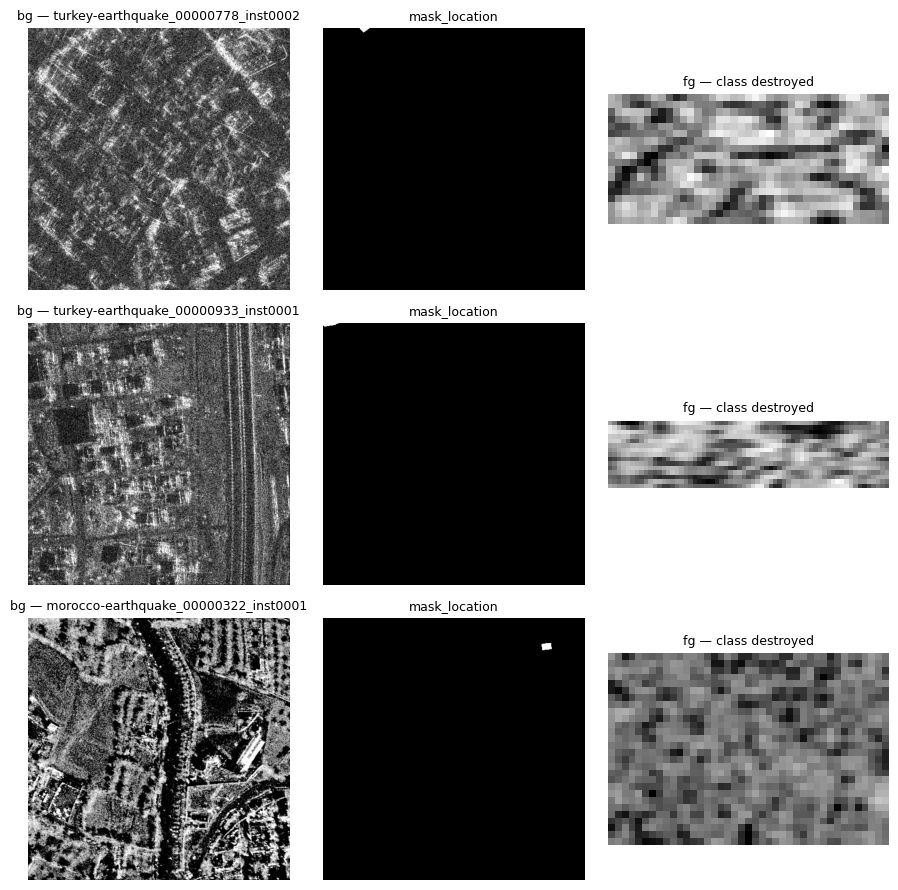

In [5]:
import matplotlib.pyplot as plt
from PIL import Image
import json, random

random.seed(0)
sample_dirs = random.sample(instance_dirs, min(3, len(instance_dirs)))

fig, axes = plt.subplots(len(sample_dirs), 3, figsize=(9, 3 * len(sample_dirs)))
if len(sample_dirs) == 1:
    axes = [axes]

for row, d in zip(axes, sample_dirs):
    inst_path = os.path.join(OUT_DIR, d)
    bg = Image.open(os.path.join(inst_path, 'bg.png'))
    mask = Image.open(os.path.join(inst_path, 'mask_location.png'))
    fg = Image.open(os.path.join(inst_path, 'fg.png'))
    with open(os.path.join(inst_path, 'meta.json')) as f:
        meta = json.load(f)

    row[0].imshow(bg); row[0].set_title(f"bg — {d}", fontsize=9); row[0].axis('off')
    row[1].imshow(mask, cmap='gray'); row[1].set_title("mask_location", fontsize=9); row[1].axis('off')
    row[2].imshow(fg); row[2].set_title(f"fg — class {meta['class_name']}", fontsize=9); row[2].axis('off')

plt.tight_layout()
plt.show()

## 7. updated_label.tif gercekten guncellenmis mi kontrol et
Secilen instance bolgesinde artik 2 (damaged) veya 3 (destroyed) degeri olmali, orijinalde 1 (intact) idi.

In [6]:
import rasterio
import numpy as np

d = sample_dirs[0]
inst_path = os.path.join(OUT_DIR, d)
with open(os.path.join(inst_path, 'meta.json')) as f:
    meta = json.load(f)

x1, y1, x2, y2 = meta['bbox_px']

with rasterio.open(os.path.join(inst_path, 'updated_label.tif')) as src:
    updated_arr = src.read(1)

region = updated_arr[y1:y2, x1:x2]
vals, counts = np.unique(region, return_counts=True)
print(f"instance: {d}")
print(f"beklenen damage_class: {meta['damage_class']} ({meta['class_name']})")
print("updated_label bolgesindeki degerler:", dict(zip(vals.tolist(), counts.tolist())))

instance: turkey-earthquake_00000778_inst0002
beklenen damage_class: 3 (destroyed)
updated_label bolgesindeki degerler: {0: 311, 3: 391}


TAMAMLANAN VERİ KÜMESİ ANALİZİ


In [10]:
import re
import pandas as pd
from pandas import DataFrame as df
def extract_event(scene_id):
    return re.sub(r'_\d+$', '', scene_id)  # "turkey-earthquake_00000778" -> "turkey-earthquake"
df=pd.read_csv(CSV_PATH)
csv_events = df['image_name'].apply(extract_event).value_counts()
print("CSV'deki (1497 sahne) event dagilimi:")
print(csv_events)

mask_files = os.listdir(MASKS_DIR)
mask_scene_ids = set(f.replace('_building_damage.tif', '') for f in mask_files)
mask_events = pd.Series([extract_event(s) for s in mask_scene_ids]).value_counts()
print("\nKopyalanan (raw/target'taki) sahne event dagilimi:")
print(mask_events)

csv_scenes_per_event = df.groupby(df['image_name'].apply(extract_event))['image_name'].nunique()
print("CSV'deki BENZERSIZ sahne sayisi (event basina):")
print(csv_scenes_per_event)

for event in mask_events.index:
    copied = mask_events[event]
    in_csv = csv_scenes_per_event.get(event, 0)
    print(f"{event}: kopyalanan={copied}, CSV'de damage iceren sahne={in_csv}, oran=%{100*in_csv/copied:.1f}")

CSV'deki (1497 sahne) event dagilimi:
image_name
ukraine-conflict      6760
mexico-hurricane      5731
la_palma-volcano      5109
turkey-earthquake     4074
hawaii-wildfire       2597
libya-flood           1764
congo-volcano         1692
myanmar-hurricane      892
noto-earthquake        799
marshall-wildfire      787
bata-explosion         473
beirut-explosion       377
haiti-earthquake       121
morocco-earthquake      60
Name: count, dtype: int64

Kopyalanan (raw/target'taki) sahne event dagilimi:
turkey-earthquake     1114
morocco-earthquake     567
noto-earthquake         79
haiti-earthquake        73
Name: count, dtype: int64
CSV'deki BENZERSIZ sahne sayisi (event basina):
image_name
bata-explosion         39
beirut-explosion       18
congo-volcano          19
haiti-earthquake       29
hawaii-wildfire        53
la_palma-volcano      161
libya-flood            42
marshall-wildfire      26
mexico-hurricane      166
morocco-earthquake     25
myanmar-hurricane      46
noto-earthquake 